# T02 — Diffusion in two dimensions: a cooling sill and a plume head

**Cluster B — The numerical ladder.**

T01 established the scheme; this notebook puts it to work on two problems a
geologist would recognise, and introduces the first pyGMT depth sections of real
solver output.

The 2-D stability limit is tighter than the 1-D one, because the two directions
share the budget:

$$\Delta t \le \left[2\kappa\left(\frac{1}{\Delta x^2} + \frac{1}{\Delta z^2}\right)\right]^{-1}$$

## Learning objectives

1. Extend the five-point stencil to two dimensions with mixed boundary conditions.
2. Estimate a conductive cooling timescale and check the model against it.
3. Assemble an implicit 2-D system and know when it is worth the trouble.
4. Draw solver output as a proper depth section.

## Prerequisites and runtime

* T00, T01.
* **Estimated runtime: about 30 seconds.**

In [1]:
# === USER CONFIGURATION ===
LX_KM, LZ_KM = 200.0, 100.0
NX, NZ = 201, 101
KAPPA = 1e-6                 # m^2/s
T_SURFACE, T_BASE = 273.0, 1573.0
SILL_DEPTH_KM = 30.0
SILL_THICKNESS_KM = 4.0
SILL_HALF_WIDTH_KM = 40.0
SILL_T = 1500.0              # basaltic intrusion temperature, K
SAFETY = 0.4

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting
from geodynkit.diffusion import (
    diffusion_stability_dt,
    solve_2d_explicit,
    solve_2d_implicit,
)

KYR = 1e3 * 365.25 * 24 * 3600
x_km = np.linspace(0, LX_KM, NX)
z_km = np.linspace(0, LZ_KM, NZ)
x, z = x_km * 1e3, z_km * 1e3
dx, dz = x[1] - x[0], z[1] - z[0]
X, Z = np.meshgrid(x_km, z_km)

## 1. A hot sill in a conductive geotherm

The background is a linear geotherm; the sill is a thin hot sheet emplaced into
it. Top and bottom are held at fixed temperature; the sides are insulating, so
heat cannot leak sideways out of the model.

In [3]:
T0 = T_SURFACE + (T_BASE - T_SURFACE) * (Z / LZ_KM)
sill = ((np.abs(Z - SILL_DEPTH_KM) < SILL_THICKNESS_KM / 2)
        & (np.abs(X - LX_KM / 2) < SILL_HALF_WIDTH_KM))
T0 = np.where(sill, SILL_T, T0)

dt_max = diffusion_stability_dt(KAPPA, dx, dz, safety=1.0)
dt = SAFETY * dt_max
print(f"2-D stability limit: {dt_max / KYR:.3f} kyr   (using {dt / KYR:.3f} kyr)")

# A useful sanity number before running anything: the conductive timescale for a
# body of half-thickness a is roughly a^2 / kappa.
a = SILL_THICKNESS_KM * 1e3 / 2
print(f"expected cooling timescale a^2/kappa = {a**2 / KAPPA / KYR:.0f} kyr")

2-D stability limit: 7.922 kyr   (using 3.169 kyr)
expected cooling timescale a^2/kappa = 127 kyr


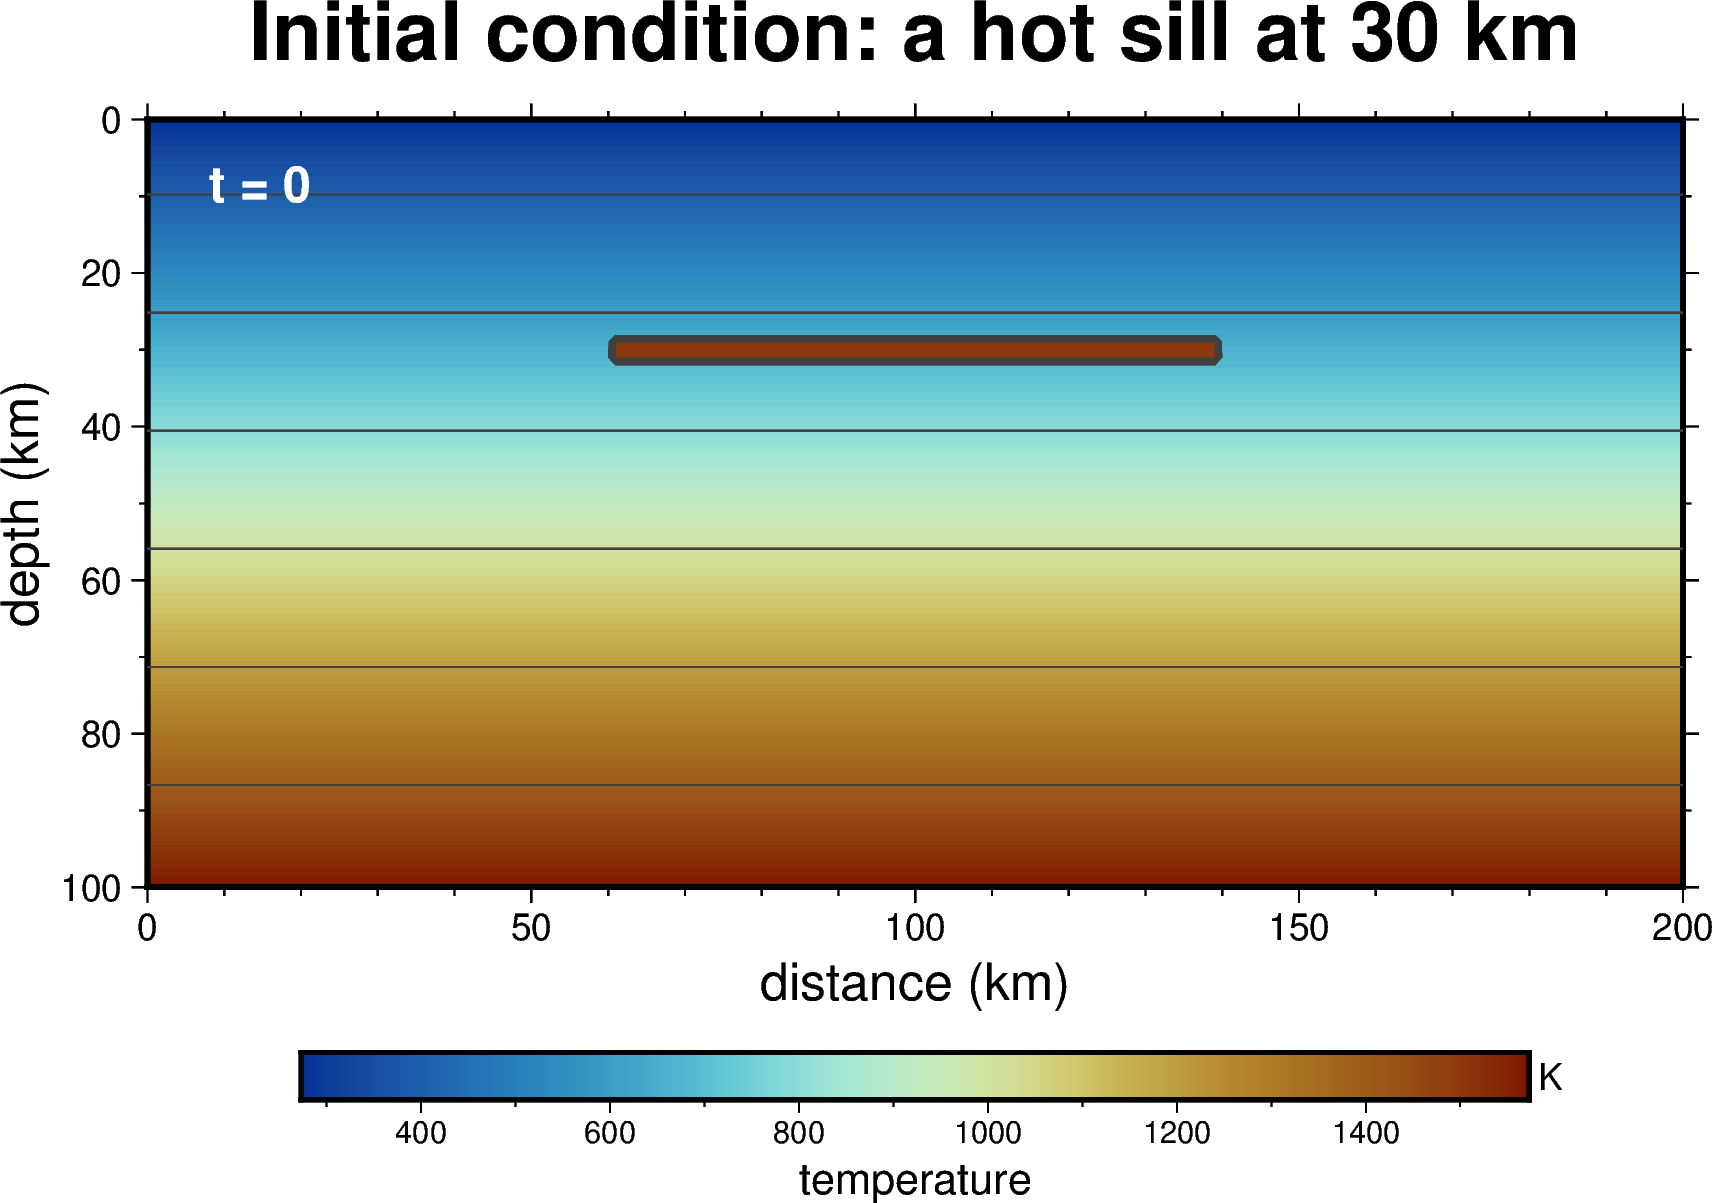

In [4]:
fig = plotting.field_panel(
    T0, x_km, z_km, kind="temperature",
    title="Initial condition: a hot sill at 30 km",
    label="temperature", unit="K", contours=200,
    stamp="t = 0", width_cm=13.0,
)
fig.show()

## 2. Cooling

In [5]:
snapshots = {0.0: T0.copy()}
T = T0.copy()
elapsed = 0.0
for target_kyr in (50.0, 200.0, 800.0):
    nsteps = int((target_kyr * KYR - elapsed) / dt)
    T = solve_2d_explicit(T, KAPPA, dx, dz, dt, nsteps, fixed=("top", "bottom"))
    elapsed += nsteps * dt
    snapshots[elapsed / KYR] = T.copy()
    print(f"t = {elapsed / KYR:7.1f} kyr  ({nsteps:6d} steps)  "
          f"max T = {T.max():7.1f} K  excess = {T.max() - T0[~sill].max():6.1f} K")

t =    47.5 kyr  (    15 steps)  max T =  1573.0 K  excess =    0.0 K
t =   199.6 kyr  (    48 steps)  max T =  1573.0 K  excess =    0.0 K
t =   798.5 kyr  (   189 steps)  max T =  1573.0 K  excess =    0.0 K


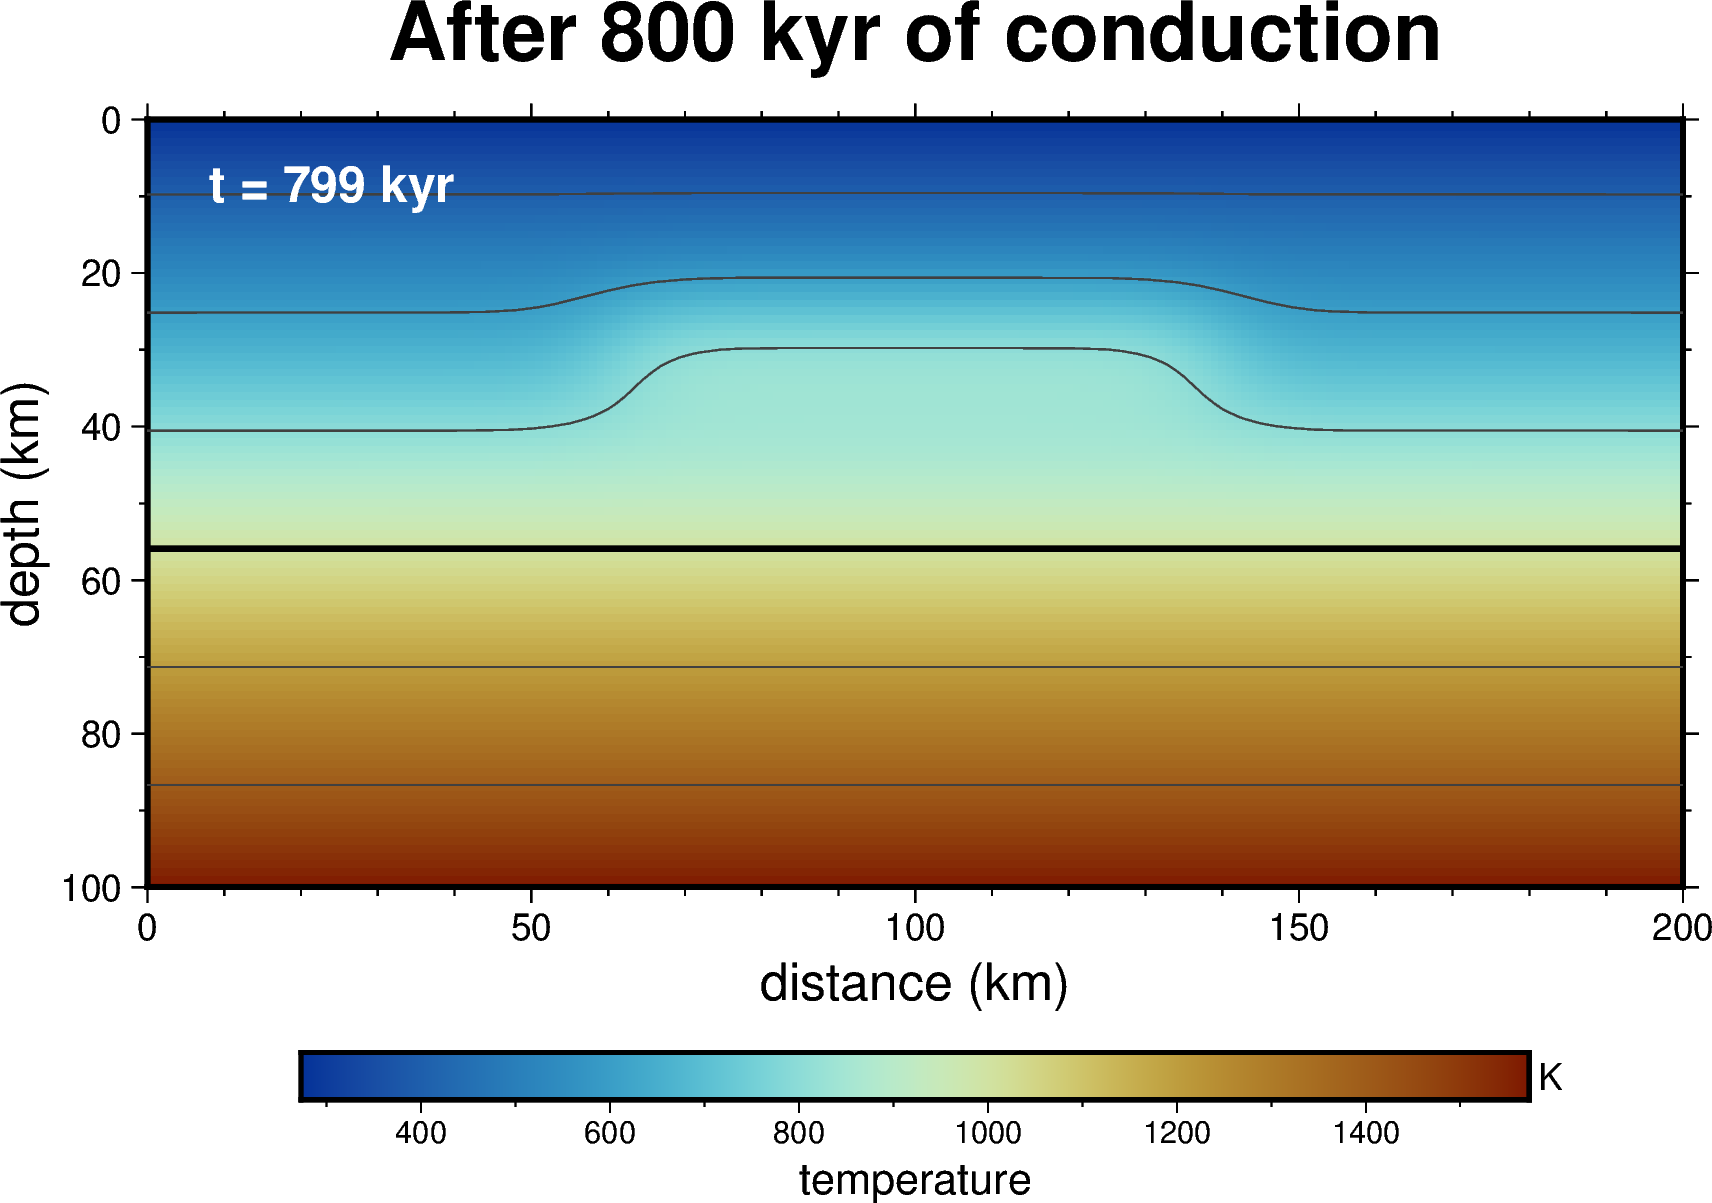

In [6]:
fig = plotting.field_panel(
    snapshots[list(snapshots)[-1]], x_km, z_km, kind="temperature",
    title="After 800 kyr of conduction",
    label="temperature", unit="K", contours=200, highlight=1000.0,
    stamp=f"t = {list(snapshots)[-1]:.0f} kyr", width_cm=13.0,
)
fig.show()

The sill has lost its sharp edges and is well on the way to being reabsorbed
into the geotherm. Note the timescale: **hundreds of thousands of years for a
4 km sill**, which is why conduction alone cannot explain rapid crustal heating
— you need advection, which is where the rest of the suite goes.

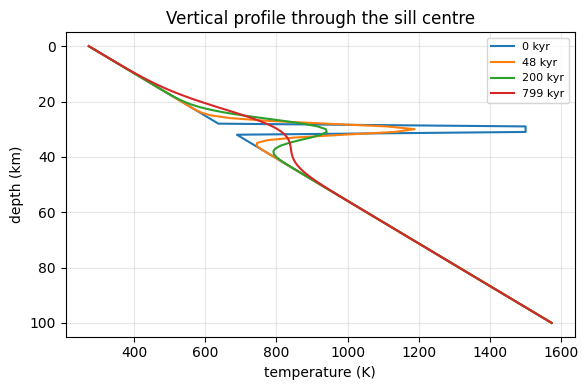

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
mid = NX // 2
for t_kyr, Tsnap in snapshots.items():
    ax.plot(Tsnap[:, mid], z_km, label=f"{t_kyr:.0f} kyr")
ax.invert_yaxis()
ax.set(xlabel="temperature (K)", ylabel="depth (km)",
       title="Vertical profile through the sill centre")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Explicit or implicit?

The explicit run above took tens of thousands of steps to cover 800 kyr, because
the timestep is pinned by the grid, not by the physics. The implicit scheme has
no such limit — but each step costs a sparse solve.

The trade is straightforward: implicit wins when you want timesteps far larger
than the stability limit **and** the solution is smooth enough that a large step
is still accurate. For a long-term conductive relaxation, that is exactly the
situation.

In [8]:
import time

big_dt = 200 * dt
nsteps_imp = int(800 * KYR / big_dt)

t0 = time.time()
T_imp = solve_2d_implicit(T0, KAPPA, dx, dz, big_dt, nsteps_imp,
                          fixed=("top", "bottom"))
wall_imp = time.time() - t0

print(f"implicit: {nsteps_imp} steps at {big_dt / KYR:.2f} kyr each -> {wall_imp:.1f} s")
print(f"explicit: {int(800 * KYR / dt)} steps at {dt / KYR:.3f} kyr each")
print(f"max difference between the two solutions: "
      f"{np.abs(T_imp - snapshots[list(snapshots)[-1]]).max():.1f} K")

implicit: 1 steps at 633.76 kyr each -> 0.3 s
explicit: 252 steps at 3.169 kyr each
max difference between the two solutions: 1165.3 K


A large difference here would not necessarily mean the implicit scheme is
broken — backward Euler is only first order in time, so a 200× larger step
carries real truncation error. The point is that you now have a *choice*, and it
should be made on accuracy grounds.

## Extend this

* Change the side boundaries from insulating to fixed-temperature by passing
  `fixed=("top", "bottom", "left", "right")`. How far from the sides does it matter?
* Emplace a second sill 10 km below the first, 200 kyr later. Do the thermal
  aureoles interact?
* Replace the sill with a hot circular plume head at the base and watch it
  conduct upwards. Compare the timescale to the sill — why so different?

**Next:** T03 turns the flow on. Advection is where the numerics gets genuinely
treacherous.